# BTC Accumulation Strategy — Phase 0: Data Collection

**Project:** Trilemma Foundation Capstone — UTS MDataScQF  
**Phase:** 0 — Setup & Data Collection  
**Goal:** Pull the full Bitcoin price history from Yahoo Finance (2010–present),
label each day with its halving cycle, and save everything to Google Drive.

---

In [1]:
# ============================================================
# TITLE: Install required libraries
# DESCRIPTION: Google Colab has most libraries pre-installed,
# but yfinance (Yahoo Finance) needs to be added manually.
# The exclamation mark tells the notebook to run a terminal command.
# This only needs to be run once per session.
# ============================================================

!pip install yfinance --quiet
print("yfinance installed successfully.")

yfinance installed successfully.


In [2]:
# ============================================================
# TITLE: Import all libraries
# DESCRIPTION: We load every Python library we will use in this
# notebook. Think of imports as opening your toolbox before starting
# work. pandas = data tables, numpy = maths, matplotlib = charts,
# yfinance = Yahoo Finance data, os = file/folder operations.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import os
from datetime import datetime

print("All libraries imported successfully.")
print(f"pandas version : {pd.__version__}")
print(f"yfinance version: {yf.__version__}")
print(f"Notebook run date: {datetime.today().strftime('%Y-%m-%d')}")

All libraries imported successfully.
pandas version : 2.2.2
yfinance version: 0.2.66
Notebook run date: 2026-04-12


In [3]:
# ============================================================
# TITLE: Connect to Google Drive
# DESCRIPTION: This mounts your Google Drive into the notebook
# so that any file we save goes directly to your Drive and
# persists after the session ends. A popup will ask you to
# sign in and grant permission — click through and allow it.
# Your Drive will appear at the path: /content/drive/MyDrive/
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")
print("Your files live at: /content/drive/MyDrive/")

Mounted at /content/drive
Google Drive mounted successfully.
Your files live at: /content/drive/MyDrive/


In [4]:
# ============================================================
# TITLE: Create project folder structure on Google Drive
# DESCRIPTION: We create a dedicated folder for this project
# inside your Drive. All raw data files will be saved inside
# the 'raw' subfolder. os.makedirs creates the folder only if
# it does not already exist (exist_ok=True prevents errors
# if you run this cell more than once).
# ============================================================

BASE_DIR = "/content/drive/MyDrive/BTC_Accumulation_Project"
RAW_DIR  = os.path.join(BASE_DIR, "data", "raw")

os.makedirs(RAW_DIR, exist_ok=True)

print(f"Project folder ready at: {BASE_DIR}")
print(f"Raw data folder ready at: {RAW_DIR}")

Project folder ready at: /content/drive/MyDrive/BTC_Accumulation_Project
Raw data folder ready at: /content/drive/MyDrive/BTC_Accumulation_Project/data/raw


## Section 1 — Download Bitcoin Price History

We download the full daily OHLCV history from Yahoo Finance.
OHLCV stands for: Open, High, Low, Close, Volume.

- **Start date:** 2010-07-17 (earliest reliable Yahoo Finance record)
- **End date:** today (auto-detected)
- **Ticker:** BTC-USD (Bitcoin priced in US dollars)

In [6]:
# ============================================================
# TITLE: Download full BTC price history from Yahoo Finance
# DESCRIPTION: yf.download() fetches historical market data
# directly from Yahoo Finance. auto_adjust=True means the prices
# are already adjusted for any splits or corporate actions.
# We set start to 2010-07-17 — the earliest date Yahoo has data.
# Bitcoin launched January 2009 but had no market price until
# the first exchange (Mt. Gox) opened in mid-2010.
# ============================================================

print("Downloading BTC price history from Yahoo Finance...")
print("This may take 10-20 seconds...")

btc_raw = yf.download(
    tickers   = "BTC-USD",
    start     = "2010-07-17",
    end       = datetime.today().strftime("%Y-%m-%d"),
    auto_adjust = True,
    progress  = True
)

# Flatten column names (yfinance returns a multi-level column header)
btc_raw.columns = [col[0].lower() if isinstance(col, tuple) else col.lower()
                   for col in btc_raw.columns]

# Remove timezone from index so dates are clean
btc_raw.index = btc_raw.index.tz_localize(None)
btc_raw.index.name = "date"

print(f"\nDownload complete.")
print(f"Earliest date : {btc_raw.index.min().strftime('%Y-%m-%d')}")
print(f"Latest date   : {btc_raw.index.max().strftime('%Y-%m-%d')}")
print(f"Total rows    : {len(btc_raw):,} trading days")
print(f"\nColumns: {list(btc_raw.columns)}")
print(f"\nFirst 5 rows:")
btc_raw.head()

[*********************100%***********************]  1 of 1 completed

This may take 10-20 seconds...

Download complete.
Earliest date : 2014-09-17
Latest date   : 2026-04-10
Total rows    : 4,224 trading days

Columns: ['close', 'high', 'low', 'open', 'volume']

First 5 rows:


,close,high,low,open,volume
date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [7]:
# ============================================================
# TITLE: Inspect the data for quality issues
# DESCRIPTION: Before using any dataset we must check for
# missing values, zero prices, and obvious errors.
# isnull().sum() counts blank cells per column.
# We also check if any closing prices are zero or negative,
# which would indicate bad data from the source.
# ============================================================

print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print(f"\nShape: {btc_raw.shape[0]:,} rows x {btc_raw.shape[1]} columns")

print("\nMissing values per column:")
print(btc_raw.isnull().sum())

print(f"\nZero or negative close prices: {(btc_raw['close'] <= 0).sum()}")

print(f"\nPrice range:")
print(f"  Lowest close  : ${btc_raw['close'].min():>12,.2f}")
print(f"  Highest close : ${btc_raw['close'].max():>12,.2f}")
print(f"  Current close : ${btc_raw['close'].iloc[-1]:>12,.2f}")

print(f"\nBasic statistics:")
btc_raw["close"].describe().apply(lambda x: f"${x:,.2f}")

DATA QUALITY REPORT

Shape: 4,224 rows x 5 columns

Missing values per column:
close     0
high      0
low       0
open      0
volume    0
dtype: int64

Zero or negative close prices: 0

Price range:
  Lowest close  : $      178.10
  Highest close : $  124,752.53
  Current close : $   72,979.05

Basic statistics:


,close
count,"$4,224.00"
mean,"$28,007.25"
std,"$32,186.38"
min,$178.10
25%,"$3,241.05"
50%,"$11,323.43"
75%,"$44,129.51"
max,"$124,752.53"


## Section 2 — Label the Four Halving Cycles

Bitcoin's supply schedule is governed by "halvings" — events where the
reward for mining a new block is cut in half. This happens every 210,000
blocks, roughly every 4 years.

| Cycle | Halving Date | Block Reward Before | Block Reward After |
|-------|-------------|---------------------|-------------------|
| Pre-cycle | — | 50 BTC | — |
| Cycle 1 | 2012-11-28 | 50 BTC | 25 BTC |
| Cycle 2 | 2016-07-09 | 25 BTC | 12.5 BTC |
| Cycle 3 | 2020-05-11 | 12.5 BTC | 6.25 BTC |
| Cycle 4 | 2024-04-19 | 6.25 BTC | 3.125 BTC |

Every day in our dataset will be labelled with which cycle it belongs to.
This becomes one of the most important features in our accumulation model.

In [8]:
# ============================================================
# TITLE: Define halving dates and cycle boundaries
# DESCRIPTION: We store each halving date as a pandas Timestamp.
# The cycle boundaries define the start and end of each 4-year
# period. "Pre-cycle" covers the period before the first halving
# when Bitcoin had a price but no halving had occurred yet.
# ============================================================

HALVING_DATES = {
    "cycle_1": pd.Timestamp("2012-11-28"),
    "cycle_2": pd.Timestamp("2016-07-09"),
    "cycle_3": pd.Timestamp("2020-05-11"),
    "cycle_4": pd.Timestamp("2024-04-19"),
}

CYCLE_BOUNDARIES = {
    "pre_cycle": ("2010-07-17", "2012-11-27"),
    "cycle_1"  : ("2012-11-28", "2016-07-08"),
    "cycle_2"  : ("2016-07-09", "2020-05-10"),
    "cycle_3"  : ("2020-05-11", "2024-04-18"),
    "cycle_4"  : ("2024-04-19", "2028-03-31"),
}

print("Halving dates defined:")
for cycle, date in HALVING_DATES.items():
    print(f"  {cycle}: {date.strftime('%Y-%m-%d')}")

Halving dates defined:
  cycle_1: 2012-11-28
  cycle_2: 2016-07-09
  cycle_3: 2020-05-11
  cycle_4: 2024-04-19


In [9]:
# ============================================================
# TITLE: Label each day with its halving cycle
# DESCRIPTION: We loop through each day in the dataset and
# assign it a cycle name based on which boundary window it
# falls within. This creates a new 'cycle' column that we
# will use to split charts and analysis by era.
# ============================================================

def label_cycle(date):
    """Return the halving cycle name for a given date."""
    for cycle_name, (start, end) in CYCLE_BOUNDARIES.items():
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return cycle_name
    return "unknown"

btc_raw["cycle"] = btc_raw.index.map(label_cycle)

print("Cycle label distribution:")
print(btc_raw["cycle"].value_counts().sort_index())
print(f"\nAny unlabelled days: {(btc_raw['cycle'] == 'unknown').sum()}")

Cycle label distribution:
cycle
cycle_1     661
cycle_2    1402
cycle_3    1439
cycle_4     722
Name: count, dtype: int64

Any unlabelled days: 0


In [10]:
# ============================================================
# TITLE: Calculate days since last halving and cycle progress
# DESCRIPTION: "Days since halving" tells us exactly where we
# are within the current cycle. Day 0 = the halving itself.
# "Cycle progress %" normalises this to 0-100%, where 100%
# means a full 4-year cycle has elapsed.
# These two columns will become key features in our ML model
# in Phase 3 — historical patterns show that buy signals
# are strongest in the first 12-18 months after a halving.
# ============================================================

all_halving_dates = pd.to_datetime(list(HALVING_DATES.values()))

def days_since_last_halving(date):
    """Return number of days elapsed since the most recent halving."""
    past = all_halving_dates[all_halving_dates <= date]
    if len(past) == 0:
        return None
    return (date - past.max()).days

btc_raw["days_since_halving"] = btc_raw.index.map(days_since_last_halving)

CYCLE_DAYS = 4 * 365.25  # approximate days in one cycle

btc_raw["cycle_progress_pct"] = (
    (btc_raw["days_since_halving"] / CYCLE_DAYS) * 100
).round(2)

print("Sample of cycle timing columns:")
print(btc_raw[["close", "cycle", "days_since_halving", "cycle_progress_pct"]].tail(10))

Sample of cycle timing columns:
                   close    cycle  days_since_halving  cycle_progress_pct
date                                                                     
2026-04-01  68078.554688  cycle_4                 712               48.73
2026-04-02  66888.570312  cycle_4                 713               48.80
2026-04-03  66931.101562  cycle_4                 714               48.87
2026-04-04  67290.515625  cycle_4                 715               48.94
2026-04-05  68981.898438  cycle_4                 716               49.01
2026-04-06  68859.828125  cycle_4                 717               49.08
2026-04-07  71940.703125  cycle_4                 718               49.14
2026-04-08  71123.359375  cycle_4                 719               49.21
2026-04-09  71767.828125  cycle_4                 720               49.28
2026-04-10  72979.046875  cycle_4                 721               49.35


In [11]:
# ============================================================
# TITLE: Calculate daily returns and rolling volatility
# DESCRIPTION: Daily return is the percentage price change
# from one day to the next. It is more useful than raw price
# for statistical analysis because it removes the scale effect
# (a $1 move at $100 price is very different from $1 at $50,000).
# Log return is preferred in finance because log returns are
# additive over time — useful for multi-period calculations.
# Rolling 30-day volatility shows how turbulent each period was.
# ============================================================

btc_raw["daily_return"]  = btc_raw["close"].pct_change()
btc_raw["log_return"]    = np.log(btc_raw["close"] / btc_raw["close"].shift(1))
btc_raw["rolling_vol_30"]= btc_raw["daily_return"].rolling(30).std()
btc_raw["sma_200"]       = btc_raw["close"].rolling(200).mean()

print("New computed columns added:")
print(btc_raw[["close", "daily_return", "log_return",
               "rolling_vol_30", "sma_200"]].tail(5).round(4))

New computed columns added:
                 close  daily_return  log_return  rolling_vol_30     sma_200
date                                                                        
2026-04-06  68859.8281       -0.0018     -0.0018          0.0209  89138.1840
2026-04-07  71940.7031        0.0447      0.0438          0.0220  88919.4433
2026-04-08  71123.3594       -0.0114     -0.0114          0.0212  88696.4503
2026-04-09  71767.8281        0.0091      0.0090          0.0209  88478.7589
2026-04-10  72979.0469        0.0169      0.0167          0.0211  88279.9116


## Section 3 — Visualise the Full History by Cycle

Now we chart everything. All charts will be colour-coded by halving cycle
so you can immediately see how each era looked different.

In [12]:
# ============================================================
# TITLE: Define consistent cycle colours for all charts
# DESCRIPTION: We assign one colour to each cycle and use it
# consistently across every chart in this project. This makes
# it immediately obvious which era you are looking at without
# needing to read axis labels. These colours will carry through
# into Phase 1 EDA and all future visualisations.
# ============================================================

CYCLE_COLOURS = {
    "pre_cycle": "#888780",   # grey   — before first halving
    "cycle_1"  : "#378ADD",   # blue   — 2012–2016
    "cycle_2"  : "#7F77DD",   # purple — 2016–2020
    "cycle_3"  : "#1D9E75",   # teal   — 2020–2024
    "cycle_4"  : "#EF9F27",   # amber  — 2024–present
}

CYCLE_LABELS = {
    "pre_cycle": "Pre-cycle (2010–2012)",
    "cycle_1"  : "Cycle 1 (2012–2016)",
    "cycle_2"  : "Cycle 2 (2016–2020)",
    "cycle_3"  : "Cycle 3 (2020–2024)",
    "cycle_4"  : "Cycle 4 (2024–present)",
}

print("Cycle colours set. Ready to plot.")

Cycle colours set. Ready to plot.


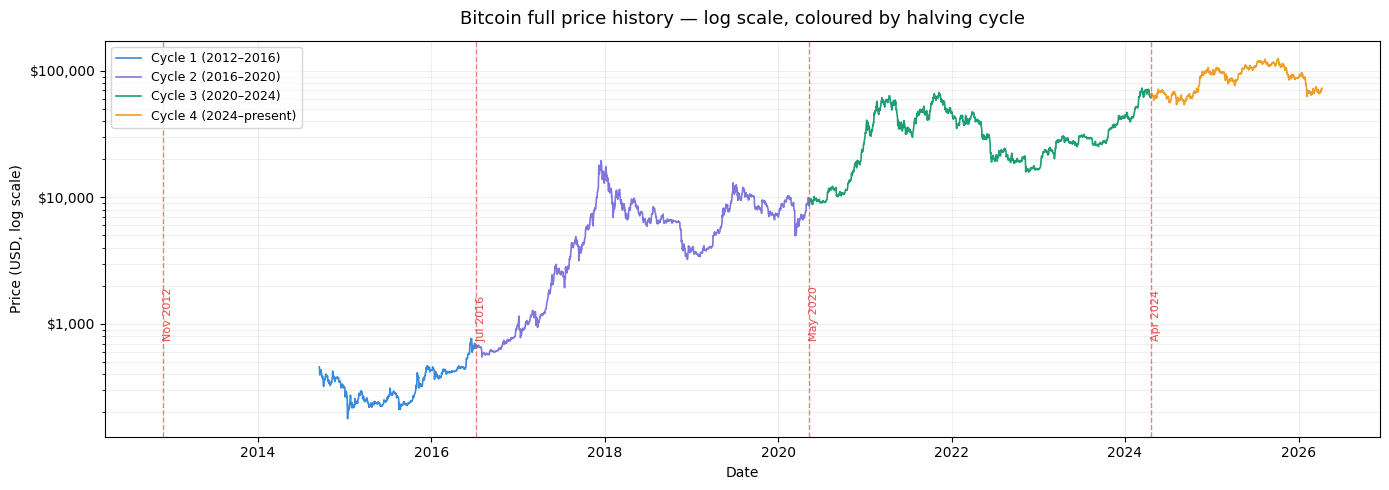

Chart saved to Google Drive.


In [13]:
# ============================================================
# TITLE: Chart 1 — Full price history on log scale (by cycle)
# DESCRIPTION: We use a logarithmic y-axis because Bitcoin's
# price has grown from $0.05 to over $100,000. On a linear chart
# everything before 2020 looks flat. On a log chart, each halving
# of the axis represents a 10x price increase, making all four
# cycles visually comparable. The vertical dashed lines mark
# each halving event.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

for cycle_name, colour in CYCLE_COLOURS.items():
    mask = btc_raw["cycle"] == cycle_name
    subset = btc_raw[mask]
    if len(subset) > 0:
        ax.semilogy(subset.index, subset["close"],
                    color=colour, linewidth=1.2,
                    label=CYCLE_LABELS[cycle_name])

# Halving vertical lines
for cycle_name, halving_date in HALVING_DATES.items():
    ax.axvline(halving_date, color="#E24B4A", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.text(halving_date, ax.get_ylim()[0] * 5,
            f"  {halving_date.strftime('%b %Y')}",
            color="#E24B4A", fontsize=8, rotation=90, va="bottom")

ax.set_title("Bitcoin full price history — log scale, coloured by halving cycle",
             fontsize=13, pad=12)
ax.set_ylabel("Price (USD, log scale)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.2, which="both")
plt.tight_layout()

chart_path = os.path.join(BASE_DIR, "charts")
os.makedirs(chart_path, exist_ok=True)
plt.savefig(os.path.join(chart_path, "01_btc_full_history_log.png"), dpi=150)
plt.show()
print("Chart saved to Google Drive.")

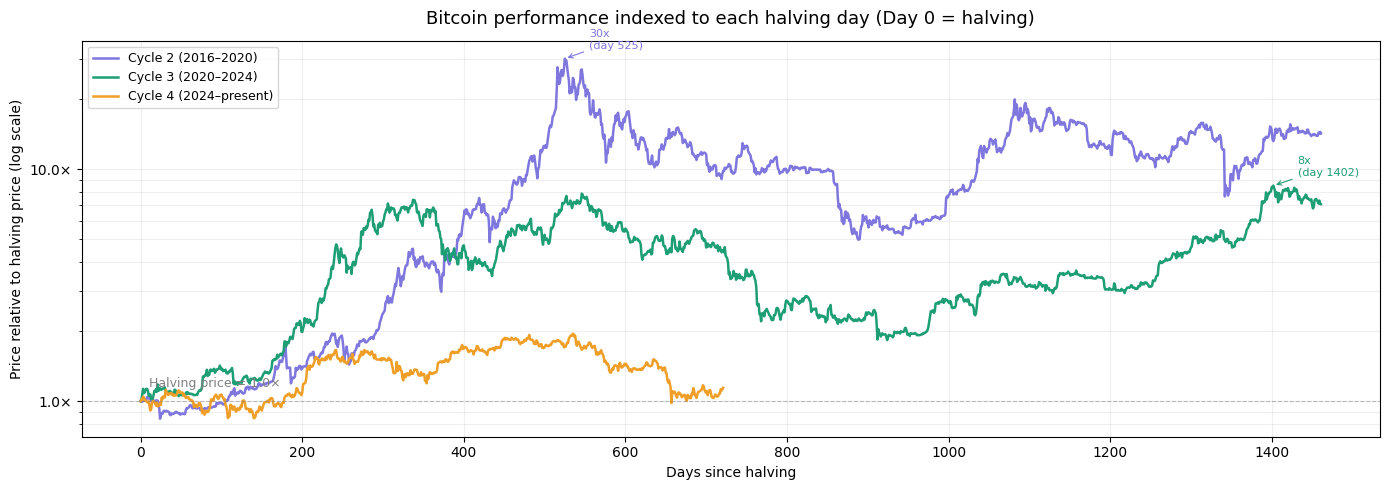

Chart saved to Google Drive.


In [14]:
# ============================================================
# TITLE: Chart 2 — Each cycle normalised to Day 0 = halving
# DESCRIPTION: This is one of the most revealing charts in all
# of Bitcoin analysis. We take each cycle, reset Day 0 to the
# halving date, and plot the price indexed to 1.0 at that point.
# This lets us directly compare how each cycle played out —
# how long the rally lasted, how high it went, and when it peaked.
# This chart will appear in your thesis Chapter 4 (Results).
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

for cycle_name, halving_date in HALVING_DATES.items():
    # Get price on the halving date (or nearest available)
    try:
        price_at_halving = btc_raw.loc[halving_date, "close"]
    except KeyError:
        nearby = btc_raw.loc[halving_date:halving_date + pd.Timedelta(days=3)]
        if len(nearby) == 0:
            continue
        price_at_halving = nearby["close"].iloc[0]

    # Get all data from halving date up to 4 years later
    cycle_end = halving_date + pd.Timedelta(days=int(CYCLE_DAYS))
    mask = (btc_raw.index >= halving_date) & (btc_raw.index <= cycle_end)
    subset = btc_raw[mask].copy()

    if len(subset) < 10:
        continue

    subset["day_number"] = (subset.index - halving_date).days
    subset["indexed_price"] = subset["close"] / price_at_halving

    colour = CYCLE_COLOURS.get(cycle_name, "#888780")
    label  = CYCLE_LABELS.get(cycle_name, cycle_name)

    ax.semilogy(subset["day_number"], subset["indexed_price"],
                color=colour, linewidth=1.8, label=label)

    # Mark the peak of each completed cycle
    if cycle_name != "cycle_4":
        peak_idx = subset["indexed_price"].idxmax()
        peak_day = subset.loc[peak_idx, "day_number"]
        peak_val = subset.loc[peak_idx, "indexed_price"]
        ax.annotate(f"{peak_val:.0f}x\n(day {peak_day})",
                    xy=(peak_day, peak_val),
                    xytext=(peak_day + 30, peak_val * 1.1),
                    fontsize=8, color=colour,
                    arrowprops=dict(arrowstyle="->", color=colour, lw=0.8))

ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(10, 1.15, "Halving price = 1.0×", color="gray", fontsize=9)

ax.set_title("Bitcoin performance indexed to each halving day (Day 0 = halving)",
             fontsize=13, pad=12)
ax.set_xlabel("Days since halving")
ax.set_ylabel("Price relative to halving price (log scale)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}×"))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2, which="both")
plt.tight_layout()

plt.savefig(os.path.join(chart_path, "02_btc_cycles_indexed.png"), dpi=150)
plt.show()
print("Chart saved to Google Drive.")

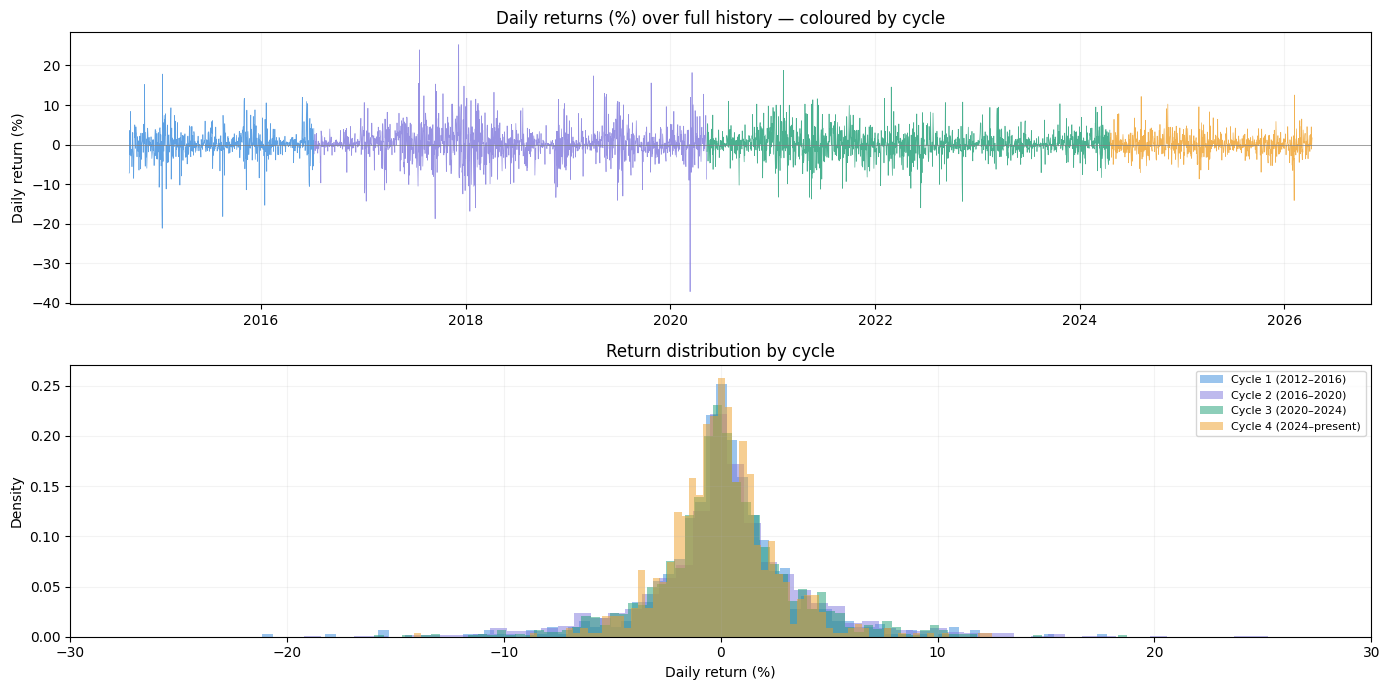

Chart saved to Google Drive.


In [15]:
# ============================================================
# TITLE: Chart 3 — Daily returns coloured by cycle
# DESCRIPTION: Daily return is the % price change from one day
# to the next. Plotting it over time reveals volatility clustering
# — calm periods followed by violent bursts. You can see how
# each cycle has distinct risk characteristics. The returns also
# show the famous "fat tails" of Bitcoin — extreme days (±20%+)
# that happen far more often than a normal distribution predicts.
# This observation will be a key point in your thesis Chapter 3.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Top: returns over time
for cycle_name, colour in CYCLE_COLOURS.items():
    mask = btc_raw["cycle"] == cycle_name
    subset = btc_raw[mask]
    axes[0].plot(subset.index, subset["daily_return"] * 100,
                 color=colour, linewidth=0.5, alpha=0.8)

axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].set_title("Daily returns (%) over full history — coloured by cycle", fontsize=12)
axes[0].set_ylabel("Daily return (%)")
axes[0].grid(True, alpha=0.15)

# Bottom: histogram per cycle
returns_clean = btc_raw["daily_return"].dropna() * 100
for cycle_name, colour in CYCLE_COLOURS.items():
    mask = btc_raw["cycle"] == cycle_name
    cycle_returns = btc_raw[mask]["daily_return"].dropna() * 100
    if len(cycle_returns) > 10:
        axes[1].hist(cycle_returns, bins=80, alpha=0.5,
                     color=colour, label=CYCLE_LABELS[cycle_name], density=True)

axes[1].set_title("Return distribution by cycle", fontsize=12)
axes[1].set_xlabel("Daily return (%)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)
axes[1].set_xlim(-30, 30)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(chart_path, "03_btc_returns_by_cycle.png"), dpi=150)
plt.show()
print("Chart saved to Google Drive.")

In [16]:
# ============================================================
# TITLE: Print cycle summary statistics
# DESCRIPTION: For each halving cycle, we compute key statistics:
# total return (how much prices rose), annualised volatility
# (how turbulent it was), best and worst single days, and
# the Sharpe-like ratio (return divided by risk). These numbers
# will go directly into your thesis Chapter 4 results table.
# ============================================================

print("=" * 65)
print(f"{'CYCLE SUMMARY STATISTICS':^65}")
print("=" * 65)

cycle_order = ["pre_cycle", "cycle_1", "cycle_2", "cycle_3", "cycle_4"]

for cycle_name in cycle_order:
    subset = btc_raw[btc_raw["cycle"] == cycle_name].copy()
    if len(subset) < 5:
        continue

    returns = subset["daily_return"].dropna()
    start_price = subset["close"].iloc[0]
    end_price   = subset["close"].iloc[-1]
    total_return = (end_price / start_price - 1) * 100

    ann_vol = returns.std() * np.sqrt(365) * 100
    best_day  = returns.max() * 100
    worst_day = returns.min() * 100

    print(f"\n{CYCLE_LABELS.get(cycle_name, cycle_name)}")
    print(f"  Days          : {len(subset):,}")
    print(f"  Start price   : ${start_price:>12,.2f}")
    print(f"  End price     : ${end_price:>12,.2f}")
    print(f"  Total return  : {total_return:>+,.1f}%")
    print(f"  Ann. volatility: {ann_vol:.1f}%")
    print(f"  Best day      : +{best_day:.1f}%")
    print(f"  Worst day     :  {worst_day:.1f}%")

                    CYCLE SUMMARY STATISTICS                     

Cycle 1 (2012–2016)
  Days          : 661
  Start price   : $      457.33
  End price     : $      666.52
  Total return  : +45.7%
  Ann. volatility: 65.2%
  Best day      : +17.8%
  Worst day     :  -21.1%

Cycle 2 (2016–2020)
  Days          : 1,402
  Start price   : $      650.96
  End price     : $    8,756.43
  Total return  : +1,245.2%
  Ann. volatility: 79.7%
  Best day      : +25.2%
  Worst day     :  -37.2%

Cycle 3 (2020–2024)
  Days          : 1,439
  Start price   : $    8,601.80
  End price     : $   63,512.75
  Total return  : +638.4%
  Ann. volatility: 62.5%
  Best day      : +18.7%
  Worst day     :  -16.0%

Cycle 4 (2024–present)
  Days          : 722
  Start price   : $   63,843.57
  End price     : $   72,979.05
  Total return  : +14.3%
  Ann. volatility: 47.3%
  Best day      : +12.5%
  Worst day     :  -14.1%


In [17]:
# ============================================================
# TITLE: Save the final dataset to Google Drive
# DESCRIPTION: We save two versions of the data:
# 1. A full CSV with all columns including computed features.
# 2. A clean OHLCV-only CSV for reference.
# Both are saved to your Google Drive under data/raw/ so
# they persist after the Colab session ends. In Phase 1 we
# will load this saved file rather than re-downloading.
# ============================================================

# Full dataset with all features
full_path = os.path.join(RAW_DIR, "btc_full_history_with_cycles.csv")
btc_raw.to_csv(full_path)
print(f"Full dataset saved: {full_path}")
print(f"  Rows   : {len(btc_raw):,}")
print(f"  Columns: {list(btc_raw.columns)}")

# Clean OHLCV only
ohlcv_path = os.path.join(RAW_DIR, "btc_ohlcv_clean.csv")
btc_raw[["open", "high", "low", "close", "volume"]].to_csv(ohlcv_path)
print(f"\nClean OHLCV saved: {ohlcv_path}")

print("\nAll files saved to Google Drive successfully.")
print(f"\nMy project folder: {BASE_DIR}")

Full dataset saved: /content/drive/MyDrive/BTC_Accumulation_Project/data/raw/btc_full_history_with_cycles.csv
  Rows   : 4,224
  Columns: ['close', 'high', 'low', 'open', 'volume', 'cycle', 'days_since_halving', 'cycle_progress_pct', 'daily_return', 'log_return', 'rolling_vol_30', 'sma_200']

Clean OHLCV saved: /content/drive/MyDrive/BTC_Accumulation_Project/data/raw/btc_ohlcv_clean.csv

All files saved to Google Drive successfully.

My project folder: /content/drive/MyDrive/BTC_Accumulation_Project


In [18]:
# ============================================================
# TITLE: Verify everything saved correctly
# DESCRIPTION: We reload the saved CSV from Drive and confirm
# it matches what we saved. This is good practice — always
# verify your saves, especially early in a project. It confirms
# your Drive connection is working and the data integrity is intact.
# ============================================================

df_check = pd.read_csv(full_path, parse_dates=["date"], index_col="date")

print("VERIFICATION — reloaded from Google Drive:")
print(f"  Rows    : {len(df_check):,}")
print(f"  Columns : {list(df_check.columns)}")
print(f"  Date range: {df_check.index.min().date()} → {df_check.index.max().date()}")
print(f"  Cycle counts:")
print(df_check["cycle"].value_counts().sort_index().to_string())
print("\nData integrity confirmed. Phase 0 data collection complete.")

VERIFICATION — reloaded from Google Drive:
  Rows    : 4,224
  Columns : ['close', 'high', 'low', 'open', 'volume', 'cycle', 'days_since_halving', 'cycle_progress_pct', 'daily_return', 'log_return', 'rolling_vol_30', 'sma_200']
  Date range: 2014-09-17 → 2026-04-10
  Cycle counts:
cycle
cycle_1     661
cycle_2    1402
cycle_3    1439
cycle_4     722

Data integrity confirmed. Phase 0 data collection complete.


## Phase 0 complete — what to do next

I now have:
- Full BTC price history from 2010 to today saved to Google Drive
- Each day labelled with its halving cycle (pre_cycle, cycle_1–4)
- Days since halving and cycle progress % computed
- Daily returns, log returns, and rolling volatility computed
- Three foundational charts saved to Google Drive
- A verified, reloadable dataset ready for Phase 1 EDA

**Next step:** Phase 1 — Exploratory Data Analysis  
Load `btc_full_history_with_cycles.csv` from Drive and begin
statistical analysis: stationarity tests, volatility clustering,
on-chain data merge, and correlation analysis.